# 01 — Exploratory Data Analysis

Validate the Lending Club data before any modeling:

1. Confirm the completed-loan target definition and measure class imbalance
2. Inspect missingness across engineered features
3. Review feature distributions and outliers
4. Check for target leakage
5. Look at feature/target relationships

The heavy lifting (target definition, feature construction, target encoding) lives in `src/features.py`. This notebook consumes that pipeline so EDA and modeling stay consistent.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make src importable when running from the notebooks/ directory
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    FEATURE_COLUMNS,
    load_lending_club_data,
    prepare_training_table,
)

DATA_PATH = PROJECT_ROOT / "data" / "accepted_2007_to_2018Q4.csv.gz"

# Sample for fast iteration. Set to None to use the full dataset.
SAMPLE_ROWS = 200_000

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

Matplotlib is building the font cache; this may take a moment.


## 1. Load data and build the training table

In [ ]:
raw = load_lending_club_data(DATA_PATH, nrows=SAMPLE_ROWS)
print(f"Raw rows loaded: {len(raw):,}")

X, y, encodings = prepare_training_table(raw)
print(f"Modeled loans (completed only): {len(X):,}")
print(f"Features: {X.shape[1]}")
X.head()

Raw rows loaded: 200,000


Modeled loans (completed only): 176,083
Features: 19


,loan_amount,term_months,interest_rate,installment,annual_income,debt_to_income_ratio,payment_to_income,loan_to_income,credit_utilization,credit_age_months,delinquency_flag,emp_length_years,open_accounts,public_records,total_accounts,mortgage_accounts,bankruptcy_records,state_default_rate,purpose_default_rate
0,3600.0,36.0,0.1399,123.03,55000.0,0.0591,0.026843,0.065455,0.297,148,0,10.0,7.0,0.0,13.0,1.0,0.0,0.206697,0.215439
1,24700.0,36.0,0.1199,820.28,65000.0,0.1606,0.151436,0.380000,0.192,192,1,10.0,22.0,0.0,38.0,4.0,0.0,0.251445,0.293958
2,20000.0,60.0,0.1078,432.66,63000.0,0.1078,0.082411,0.317460,0.562,184,0,10.0,6.0,0.0,18.0,5.0,0.0,0.179840,0.177208
4,10400.0,60.0,0.2245,289.91,104433.0,0.2537,0.033312,0.099585,0.645,210,1,3.0,12.0,0.0,35.0,6.0,0.0,0.206697,0.187842
5,11950.0,36.0,0.1344,405.18,34000.0,0.1020,0.143005,0.351471,0.684,338,0,4.0,5.0,0.0,6.0,0.0,0.0,0.177403,0.215439


## 2. Target distribution and class imbalance

A naive model can score high accuracy by predicting "no default" for everyone. Confirm the imbalance so we commit to PR-AUC and default-class F1 instead of accuracy.

              count   share
repaid (0)   140992  0.8007
default (1)   35091  0.1993

Default rate: 19.93%
Naive 'always repaid' accuracy: 80.07%


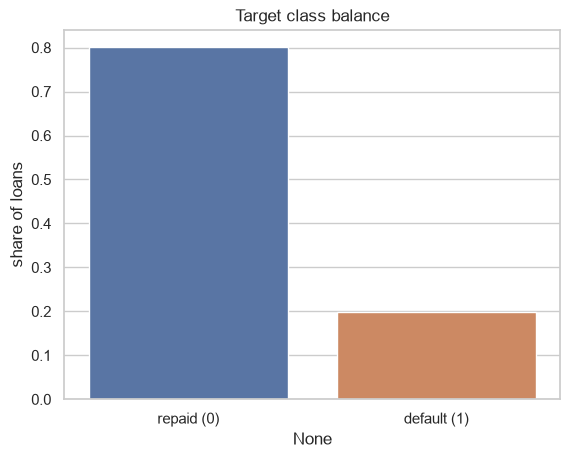

In [ ]:
counts = y.value_counts().sort_index()
rates = y.value_counts(normalize=True).sort_index()
summary = pd.DataFrame({"count": counts, "share": rates.round(4)})
summary.index = ["repaid (0)", "default (1)"]
print(summary)
print(f"\nDefault rate: {y.mean():.2%}")
print(f"Naive 'always repaid' accuracy: {(1 - y.mean()):.2%}")

ax = sns.barplot(x=summary.index, y=summary["share"], hue=summary.index, legend=False)
ax.set_title("Target class balance")
ax.set_ylabel("share of loans")
plt.show()

## 3. Missingness

Decide which features need imputation and whether any are too sparse to keep.

emp_length_years        6.323
credit_utilization      0.030
debt_to_income_ratio    0.001
payment_to_income       0.001
loan_to_income          0.001
loan_amount             0.000
open_accounts           0.000
state_default_rate      0.000
bankruptcy_records      0.000
mortgage_accounts       0.000
total_accounts          0.000
public_records          0.000
credit_age_months       0.000
delinquency_flag        0.000
term_months             0.000
annual_income           0.000
installment             0.000
interest_rate           0.000
purpose_default_rate    0.000


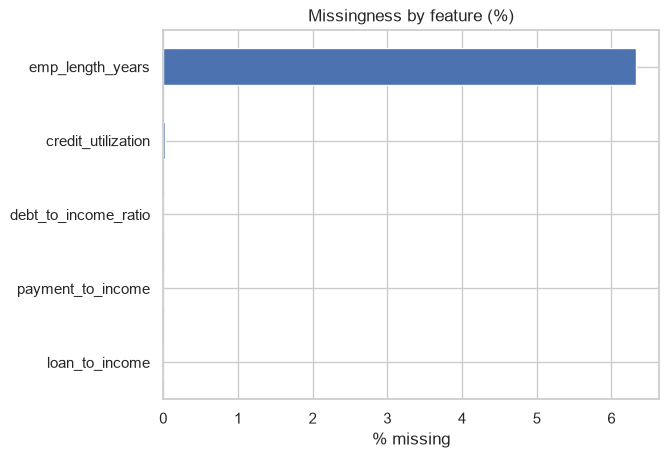

In [ ]:
missing = (X.isna().mean() * 100).sort_values(ascending=False)
print(missing.round(3).to_string())

nonzero_missing = missing[missing > 0]
if len(nonzero_missing):
    ax = nonzero_missing.plot(kind="barh")
    ax.set_title("Missingness by feature (%)")
    ax.set_xlabel("% missing")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("\nNo missing values in engineered features.")

## 4. Feature distributions and outliers

Watch for sentinel values (e.g. `dti` capped near 999, utilization above 100%) and extreme income values that distort ratios.

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
loan_amount,176083.0,14619.945,8616.186,1000.000,1650.000,8000.000,12425.000,20000.000,32500.000,35000.000,35000.000
term_months,176083.0,41.668,10.193,36.000,36.000,36.000,36.000,36.000,60.000,60.000,60.000
interest_rate,176083.0,0.121,0.042,0.053,0.053,0.084,0.120,0.146,0.192,0.240,0.290
installment,176083.0,437.107,254.623,14.770,56.560,251.360,376.010,581.050,942.590,1184.860,1445.460
annual_income,176083.0,77496.869,81659.554,0.000,18093.480,46000.000,65000.000,92000.000,158730.600,264000.000,9000000.000
debt_to_income_ratio,176081.0,0.191,0.095,0.000,0.026,0.124,0.184,0.252,0.343,0.386,9.990
payment_to_income,176081.0,0.078,0.043,0.000,0.011,0.047,0.072,0.104,0.155,0.189,4.459
loan_to_income,176081.0,0.215,0.116,0.000,0.027,0.126,0.200,0.292,0.420,0.500,10.000
credit_utilization,176030.0,0.523,0.239,0.000,0.034,0.343,0.522,0.705,0.920,0.989,1.828
credit_age_months,176083.0,201.153,92.027,37.000,47.000,138.000,182.000,248.000,377.000,488.000,791.000


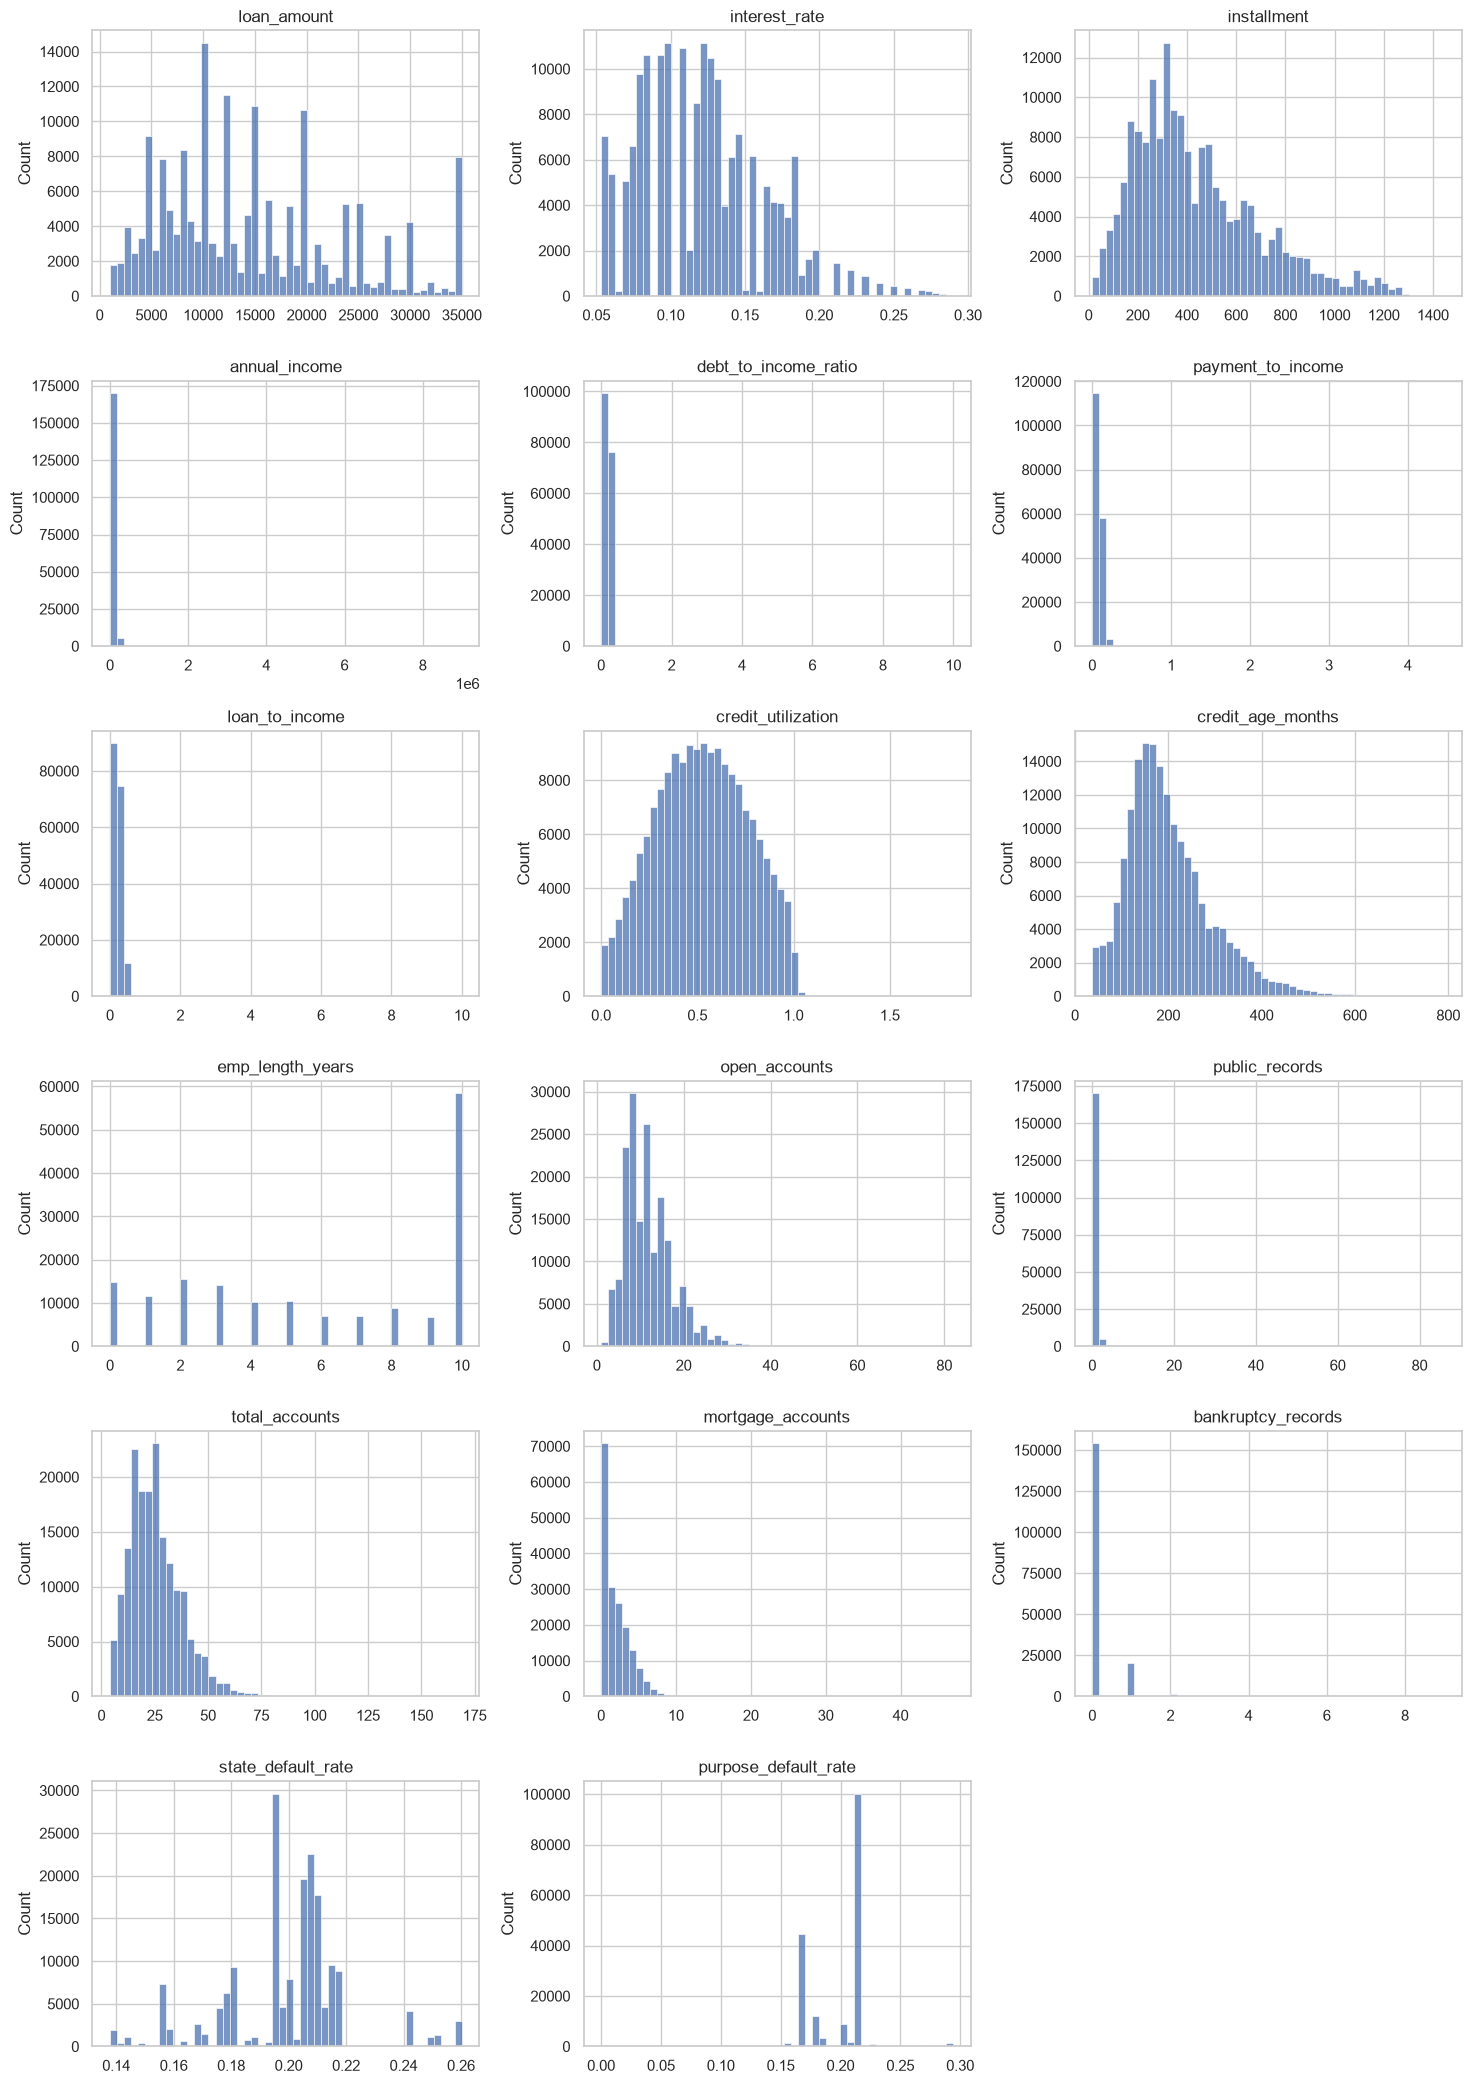

In [ ]:
display(X.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(3))

numeric_features = [c for c in FEATURE_COLUMNS if X[c].nunique() > 2]
n = len(numeric_features)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
for ax, col in zip(axes.ravel(), numeric_features):
    data = X[col].replace([np.inf, -np.inf], np.nan).dropna()
    sns.histplot(data, bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 5. Default rate by feature

Bucket continuous features and check whether default rate moves monotonically with the underwriting signal. This is a quick face-validity check before modeling.

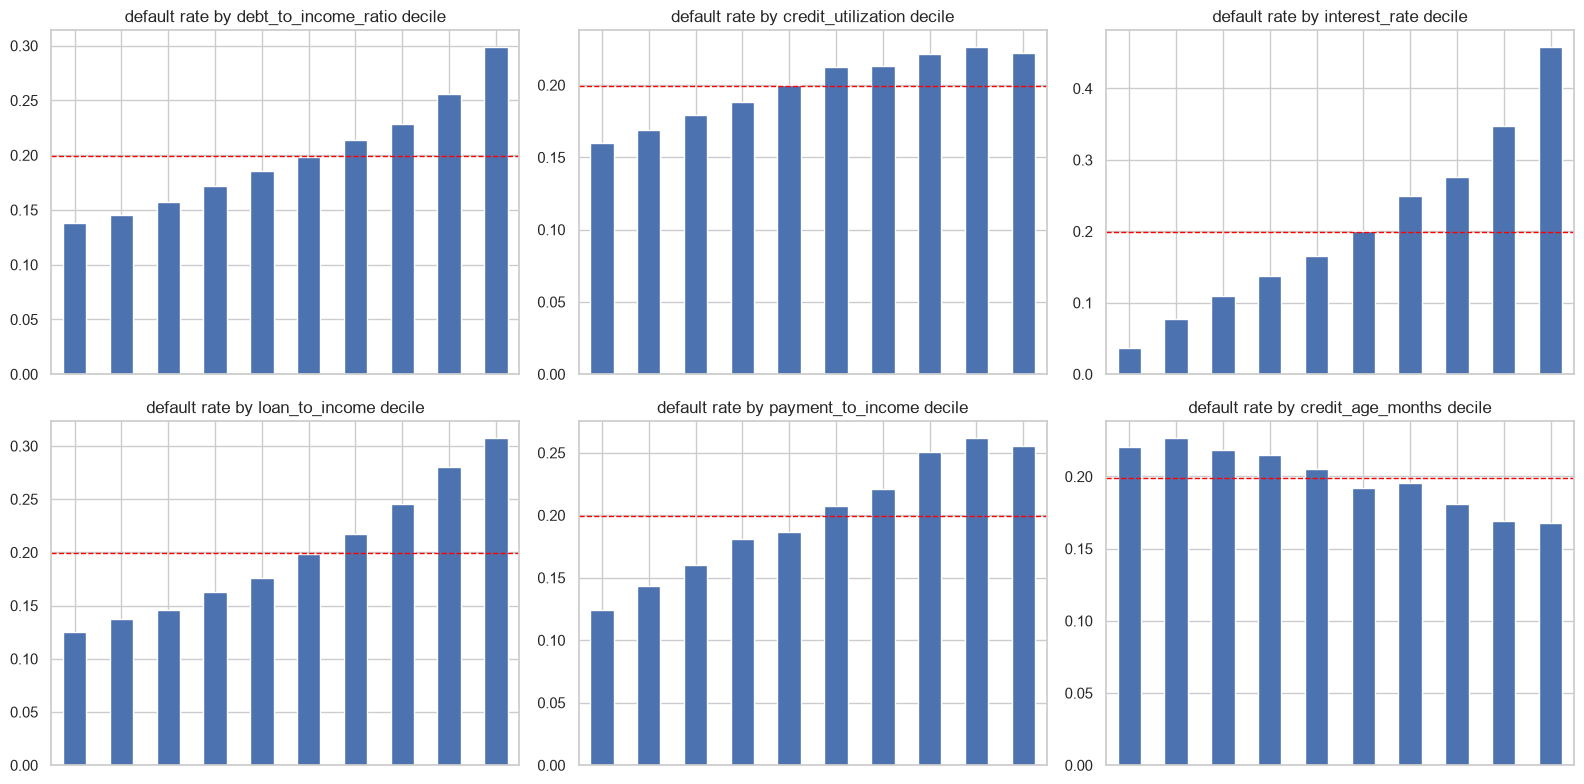

In [ ]:
signals = [
    "debt_to_income_ratio",
    "credit_utilization",
    "interest_rate",
    "loan_to_income",
    "payment_to_income",
    "credit_age_months",
]

df = X.copy()
df["default"] = y.values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), signals):
    buckets = pd.qcut(df[col], q=10, duplicates="drop")
    rate = df.groupby(buckets, observed=True)["default"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.axhline(df["default"].mean(), color="red", linestyle="--", linewidth=1)
    ax.set_title(f"default rate by {col} decile")
    ax.set_xlabel("")
    ax.set_xticklabels([])
plt.tight_layout()
plt.show()

## 6. Correlation and leakage check

Two concerns:

- **Multicollinearity** among engineered features (expected between `installment`, `loan_amount`, and the income ratios).
- **Leakage**: any feature that is suspiciously predictive because it encodes the outcome. The target encodings (`state_default_rate`, `purpose_default_rate`) are fit on the full sample here, so a strong correlation is partly self-fulfilling — during modeling these must be fit on the training split only.

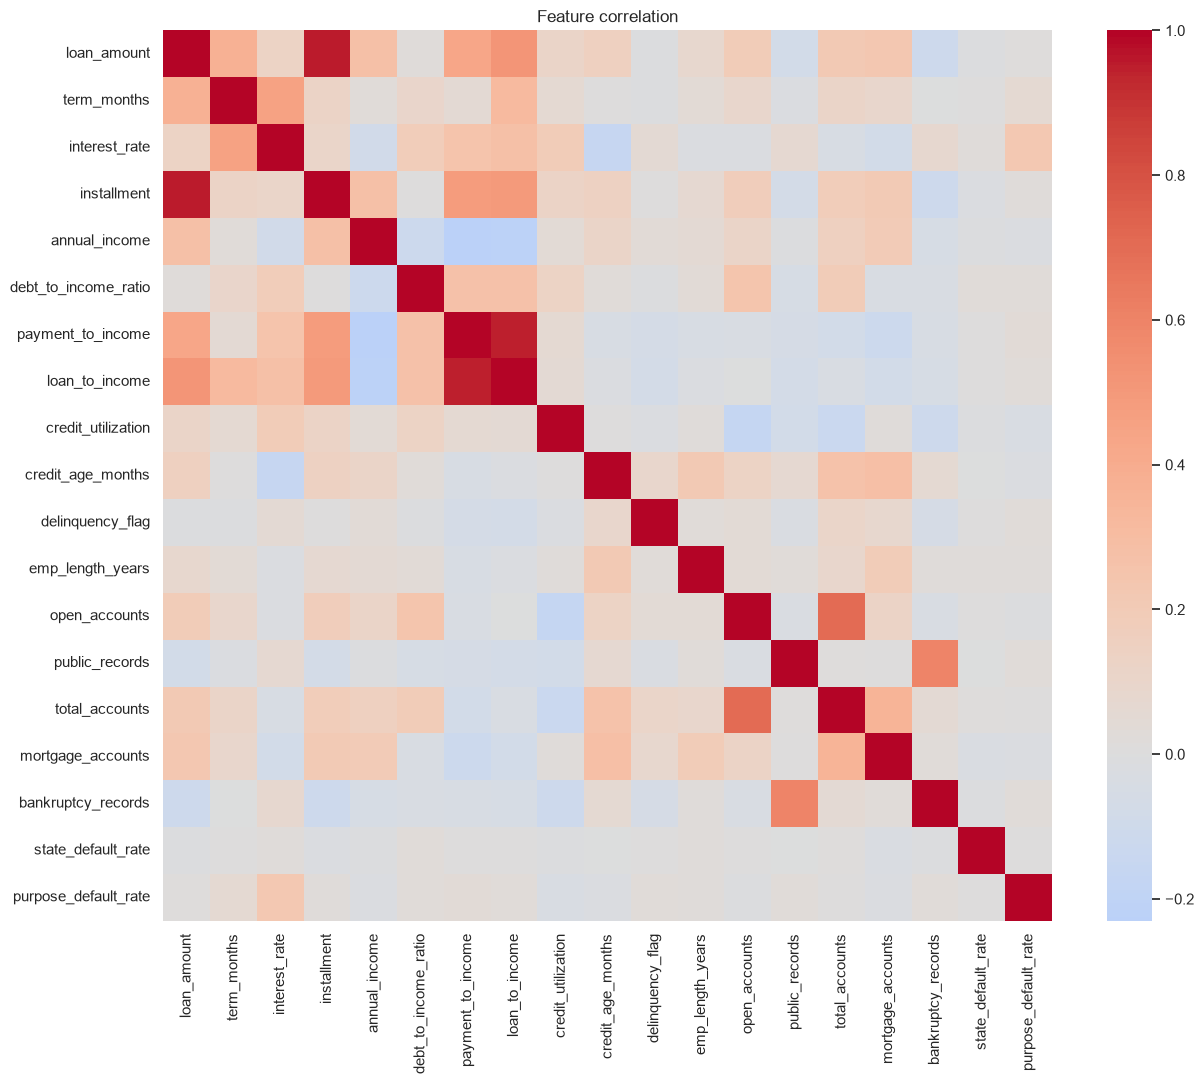

Correlation with default target:
interest_rate           0.3090
term_months             0.2395
loan_to_income          0.1415
debt_to_income_ratio    0.1085
payment_to_income       0.1030
loan_amount             0.0667
mortgage_accounts      -0.0634
purpose_default_rate    0.0608
credit_utilization      0.0541
state_default_rate      0.0534
credit_age_months      -0.0443
open_accounts           0.0425
annual_income          -0.0406
installment             0.0338
bankruptcy_records      0.0338
public_records          0.0286
total_accounts          0.0174
delinquency_flag        0.0164
emp_length_years       -0.0120


In [ ]:
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

target_corr = (
    df[FEATURE_COLUMNS + ["default"]]
    .corr()["default"]
    .drop("default")
    .sort_values(key=abs, ascending=False)
)
print("Correlation with default target:")
print(target_corr.round(4).to_string())

## Takeaways

_Fill in after running:_

- Default rate on the sample and the metric choice it justifies
- Features needing imputation
- Sentinel/outlier handling to add to `features.py` (e.g. capping `dti`)
- Candidate features to drop for redundancy
- Confirmation that target encodings must be fit on the training split only

**Next:** implement the train/validation/test split and baseline models in `src/train.py`.